## Load Processed data

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/time_series_features.csv")

df["appointmentday"] = pd.to_datetime(df["appointmentday"])
df.set_index("appointmentday", inplace=True)

df.head()

,patient_count,day_of_week,target,lag_1,lag_3,lag_7,rolling_mean_3,rolling_std_3,month,day_of_month,is_weekend
appointmentday,,,,,,,,,,,
2016-05-06,3084.0,4,0.0,3466.0,3425.0,2602.0,3248.333333,196.505301,5,6,0
2016-05-07,0.0,5,0.0,3084.0,3195.0,0.0,2183.333333,1900.444509,5,7,1
2016-05-08,0.0,6,3501.0,0.0,3466.0,0.0,1028.000000,1780.548230,5,8,1
2016-05-09,3501.0,0,3316.0,0.0,3084.0,3515.0,1167.000000,2021.303292,5,9,0
2016-05-10,3316.0,1,3589.0,3501.0,0.0,3425.0,2272.333333,1970.071149,5,10,0


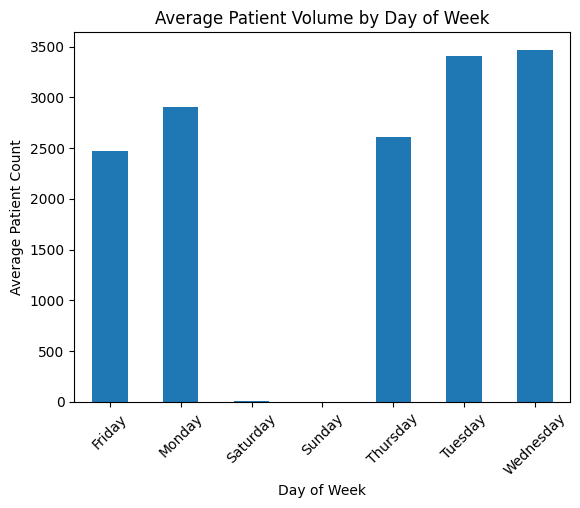

In [2]:
import matplotlib.pyplot as plt
df["day_name"] = df.index.day_name()

df.groupby("day_name")["patient_count"].mean().plot(kind="bar")

plt.title("Average Patient Volume by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Patient Count")
plt.xticks(rotation=45)
plt.show()

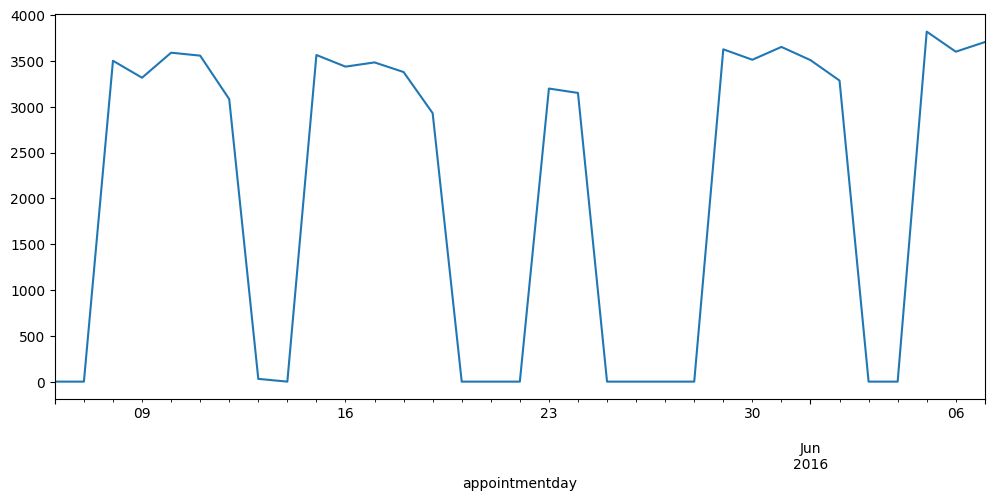

In [3]:
df['target'].plot(figsize=(12,5));

In [4]:
df.select_dtypes(include='number').corr()

,patient_count,day_of_week,target,lag_1,lag_3,lag_7,rolling_mean_3,rolling_std_3,month,day_of_month,is_weekend
patient_count,1.000000,-0.715120,0.402385,0.395034,-0.362906,0.614451,0.572836,-0.154132,0.149327,-0.211772,-0.813146
day_of_week,-0.715120,1.000000,-0.483187,-0.051122,0.483356,-0.721731,-0.077823,-0.150142,-0.007662,-0.076499,0.793554
target,0.402385,-0.483187,1.000000,-0.222907,-0.380694,0.263178,-0.109973,0.043951,0.144576,-0.118223,-0.248650
lag_1,0.395034,-0.051122,-0.222907,1.000000,-0.193792,0.246129,0.883690,-0.255892,0.147004,-0.306266,-0.325144
lag_3,-0.362906,0.483356,-0.380694,-0.193792,1.000000,-0.399231,-0.052696,-0.105754,0.114922,-0.336185,0.382859
lag_7,0.614451,-0.721731,0.263178,0.246129,-0.399231,1.000000,0.280100,-0.063203,-0.174081,0.091617,-0.811539
rolling_mean_3,0.572836,-0.077823,-0.109973,0.883690,-0.052696,0.280100,1.000000,-0.371155,0.218952,-0.455697,-0.452078
rolling_std_3,-0.154132,-0.150142,0.043951,-0.255892,-0.105754,-0.063203,-0.371155,1.000000,0.002522,0.069058,0.189981
month,0.149327,-0.007662,0.144576,0.147004,0.114922,-0.174081,0.218952,0.002522,1.000000,-0.661483,-0.019551
day_of_month,-0.211772,-0.076499,-0.118223,-0.306266,-0.336185,0.091617,-0.455697,0.069058,-0.661483,1.000000,-0.009142


<Axes: xlabel='month'>

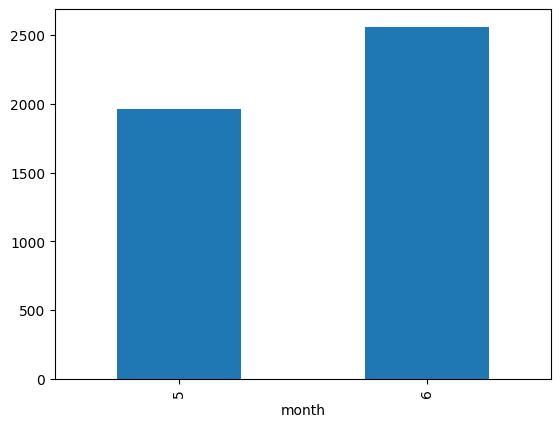

In [7]:
df.groupby('month')['target'].mean().plot(kind='bar')
# df.groupby('day_of_month')['target'].mean()

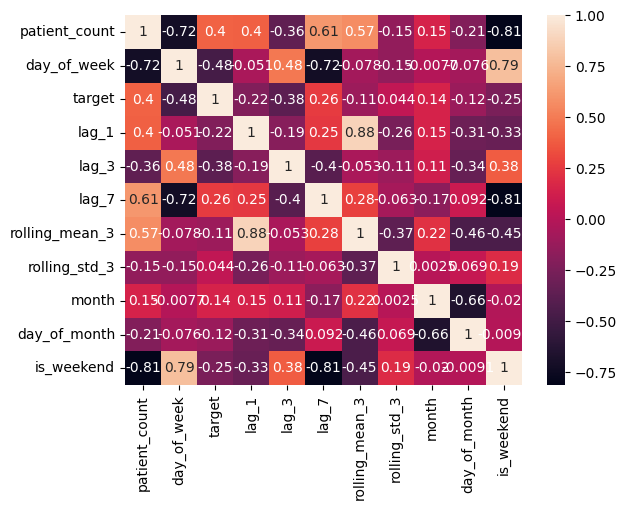

In [9]:
import seaborn as sns
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True);

Explicitly analyzing trend and seasonality  

Use seasonal decomposition (trend + seasonality + residuals)
This will tell you:
Is there a long-term upward/downward trend?
Is weekly seasonality strong?
Are there irregular spikes?

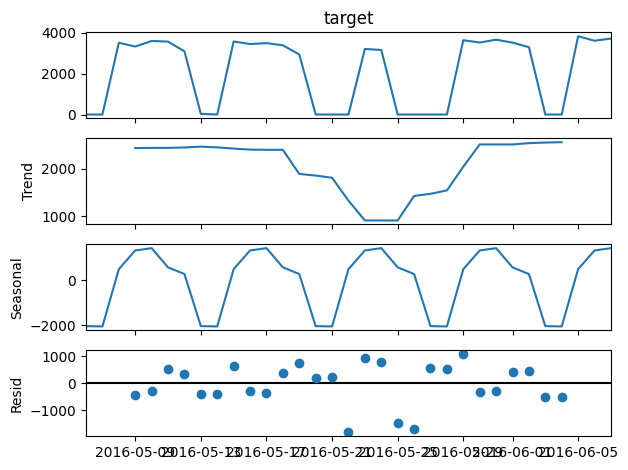

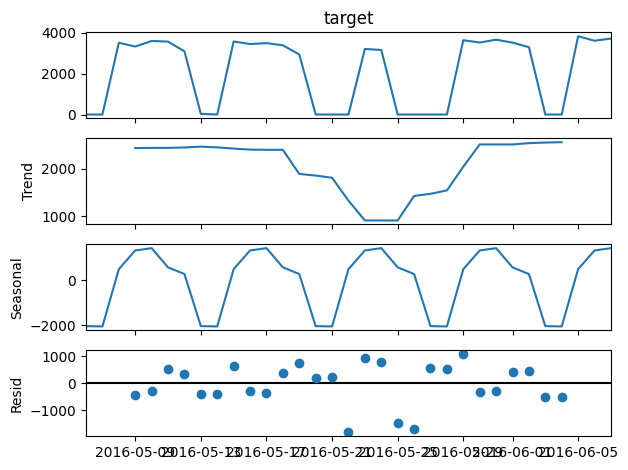

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['target'], period=7)
decomposition.plot()

Visual dependency between lag features

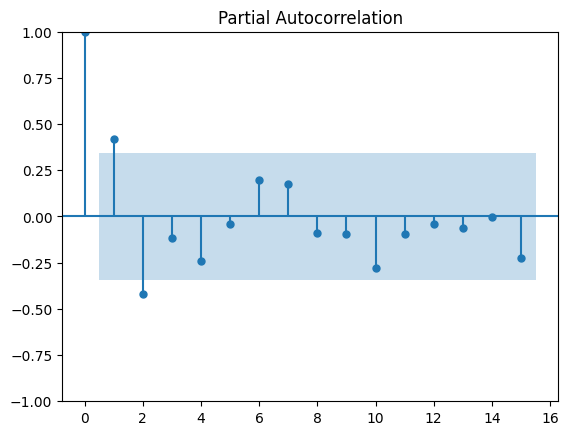

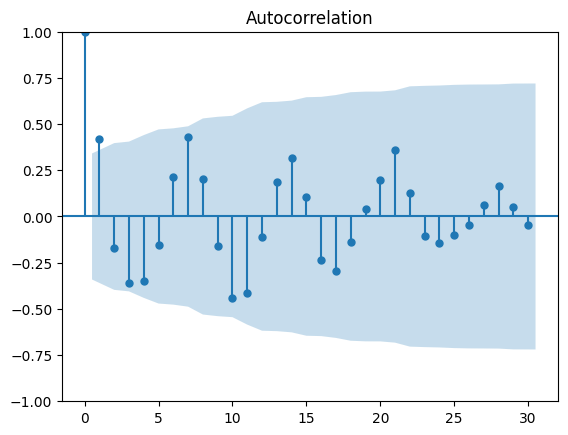

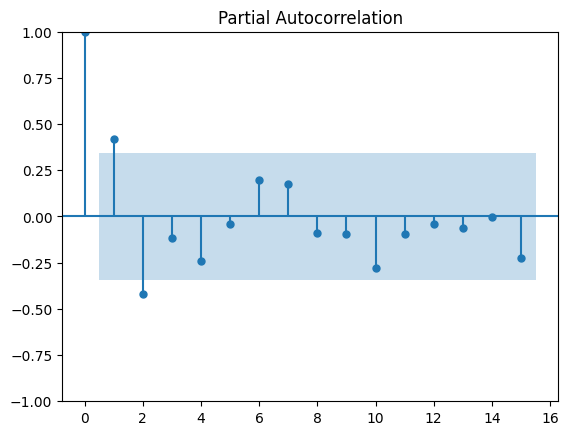

In [17]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df['target'], lags=30)
plot_pacf(df['target'], lags=15)

Distribution Analysis

<Axes: xlabel='target'>

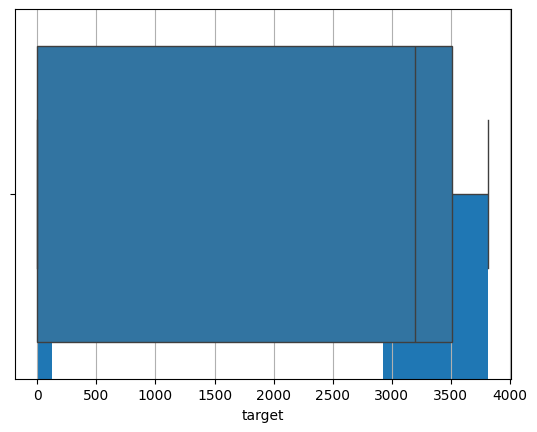

In [10]:
df['target'].hist(bins=30)
sns.boxplot(x=df['target'])

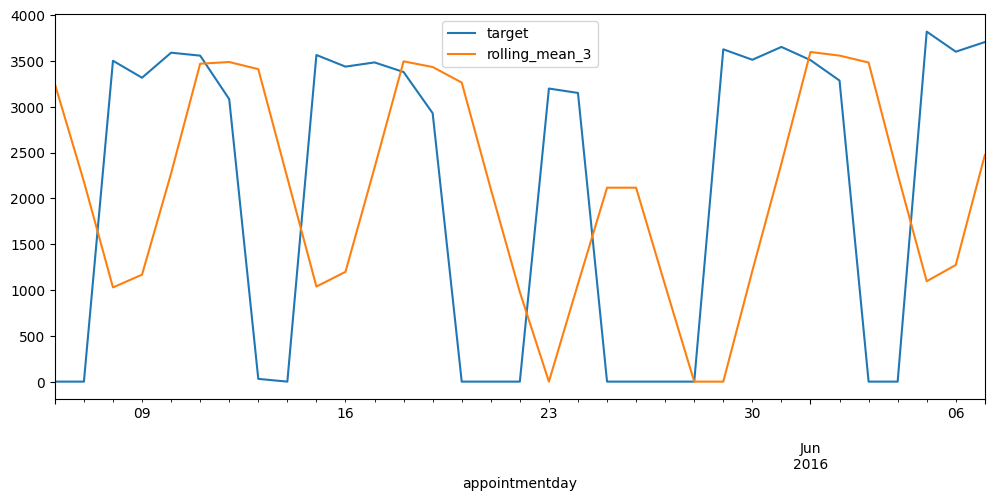

In [19]:
df[['target', 'rolling_mean_3']].plot(figsize=(12,5));

Test if the series is stationary

In [18]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['target'].dropna())
print(result)

(np.float64(-4.591592314249336), np.float64(0.00013385806844416743), 1, 31, {'1%': np.float64(-3.661428725118324), '5%': np.float64(-2.960525341210433), '10%': np.float64(-2.6193188033298647)}, np.float64(387.0739079601442))


Feature-target relationship over time

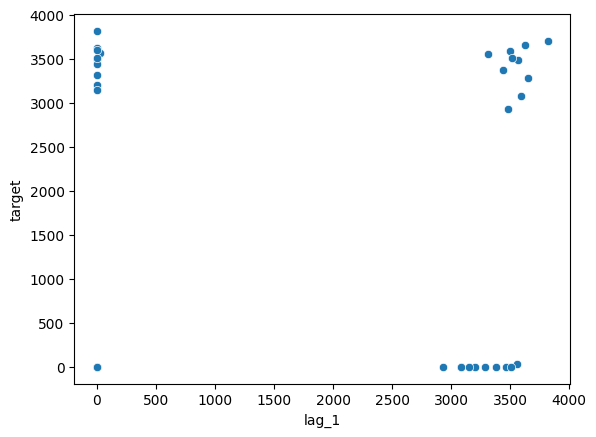

In [14]:
sns.scatterplot(x=df['lag_1'], y=df['target']);